# <img src="https://epfl-ada.github.io/assets/img/ada.svg" width="40" /> The Social Fabric They Weave

This notebook contains our analysis and its results on the Reddit dataset.

Our primary goal was to find and demonstrate measurable links between major world events (like a football match or an election) and immediate behavioral shifts inside subreddits. We focused our analysis on a few questions grouped into three main parts.

1. **Political events** (e.g. 2016 U.S. presidential election)

- How do major political events affect interaction patterns and topic trends on Reddit?

2. **Sports events** (e.g. English Premier League, the Super Bowl)

- How do major sports events and e-sports tournaments reflect in Reddit activity and community interactions?

3. **Gaming** (e.g. E-Sports)

- How does gaming affect subreddit activity?

In [6]:
from src.consts import *
from src.data import *
from src.utils import *
from src.visualization import *
from src.preprocessing import *

set_plt_style()

# Remove before sending
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Datasets

We used both the title and body datasets, respectively `df_title` and `df_body`. To get additional and interesting statistics, we also used additional datasets described below. For each dataset, we removed any data that didn't match the timestamps we needed.


- The subreddits embedding dataset `df_subreddits` represents each subreddit as a 300-dimensional vector, which we can use to compute similarities and therefore cluster subreddits to analyze different groups, like sports or politics related communities.
- The English Premier League dataset `df_english_pl` consists of a list of all English Premier League matches.
- The E-Sports tournaments dataset `df_esports` consists of a list of all esports tournaments.
- The Superbowl dataset `df_superbowl` consists of a list of all Superbowl games.

For the political part of our analysis, we primarily focused on the 2016 U.S. Presidential election and Brexit, and therefore did not need any dataset.


In [3]:
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl = load_data()

## Clustering

To start our analysis, we created clusterings to list all related subreddits between our 3 categories. This way, we were able, for example, to extract a list of left-sided political subsreddits close to `the_donald` during the 2016 US Elections.

To do this, we had to find the nearest neighbors to the manually picked subreddits and visualize them. We've tried two methods:
- Centroid-based similarity: computes the average embedding of the seed subreddits and finds subreddits closest to this centroid.
- Max similarity: finds subreddits that are closest to any of the seed subreddits.

We found that the second method yields better results. We've seen that some subreddits from the same category are not very close to each other in the embedding space, so averaging their embeddings can lead to a centroid that doesn't represent any of them well. The max similarity method ensures that we find subreddits that are closely related to at least one of the seeds, leading to more relevant results.

In [4]:
sim_gaming, sim_politics, sim_sports = similarity_subreddits(df_subreddits)

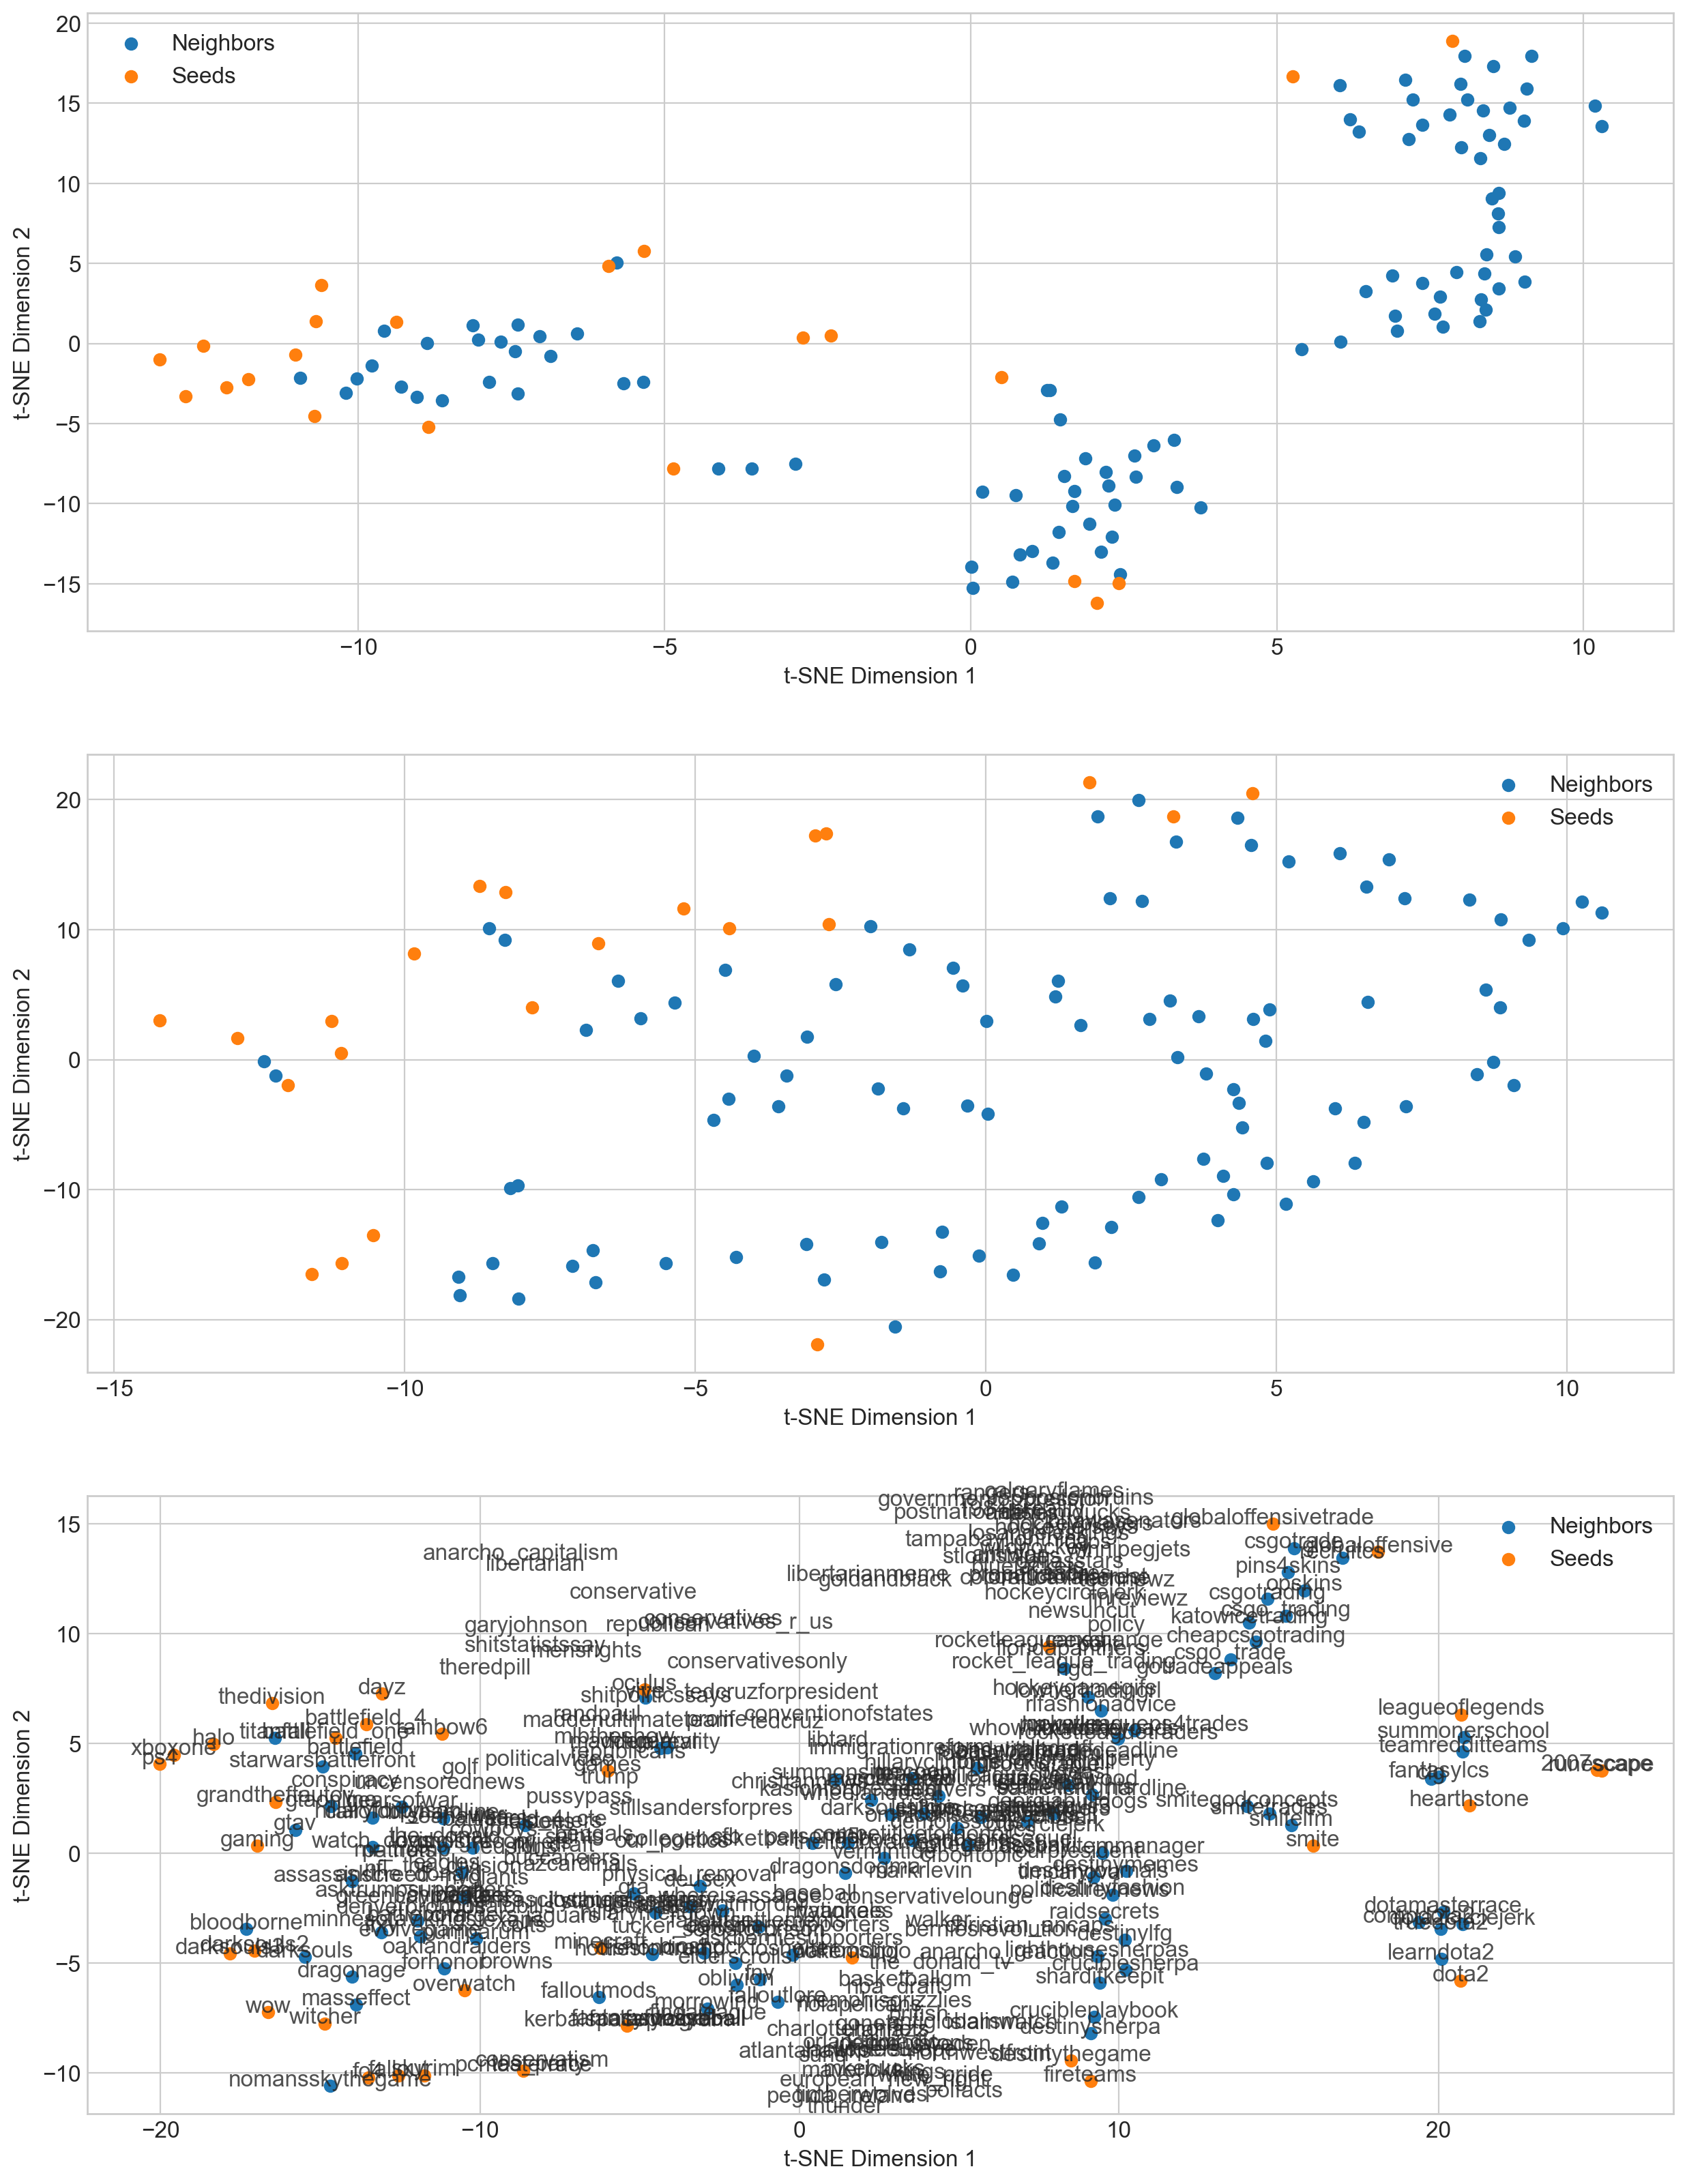

In [30]:
fig, ax = plt.subplots(3, 1, figsize=(PLOT_WIDTH, 20))

plot_neighbors_2d(ax[0], THEMES_SEEDS['sports'], sim_sports, top_n=20)
plot_neighbors_2d(ax[1], THEMES_SEEDS['politics'], sim_politics, top_n = 20)
plot_neighbors_2d(ax[2], THEMES_SEEDS['gaming'], sim_gaming, top_n = 20)

## Sports
This part focuses on the different sports datasets. Let's start with e-sports by plotting the number of mentions over time. Of course, the number is very low, but with clustering we will be able to regroup with other subreddits and have a lot more data on interactions.

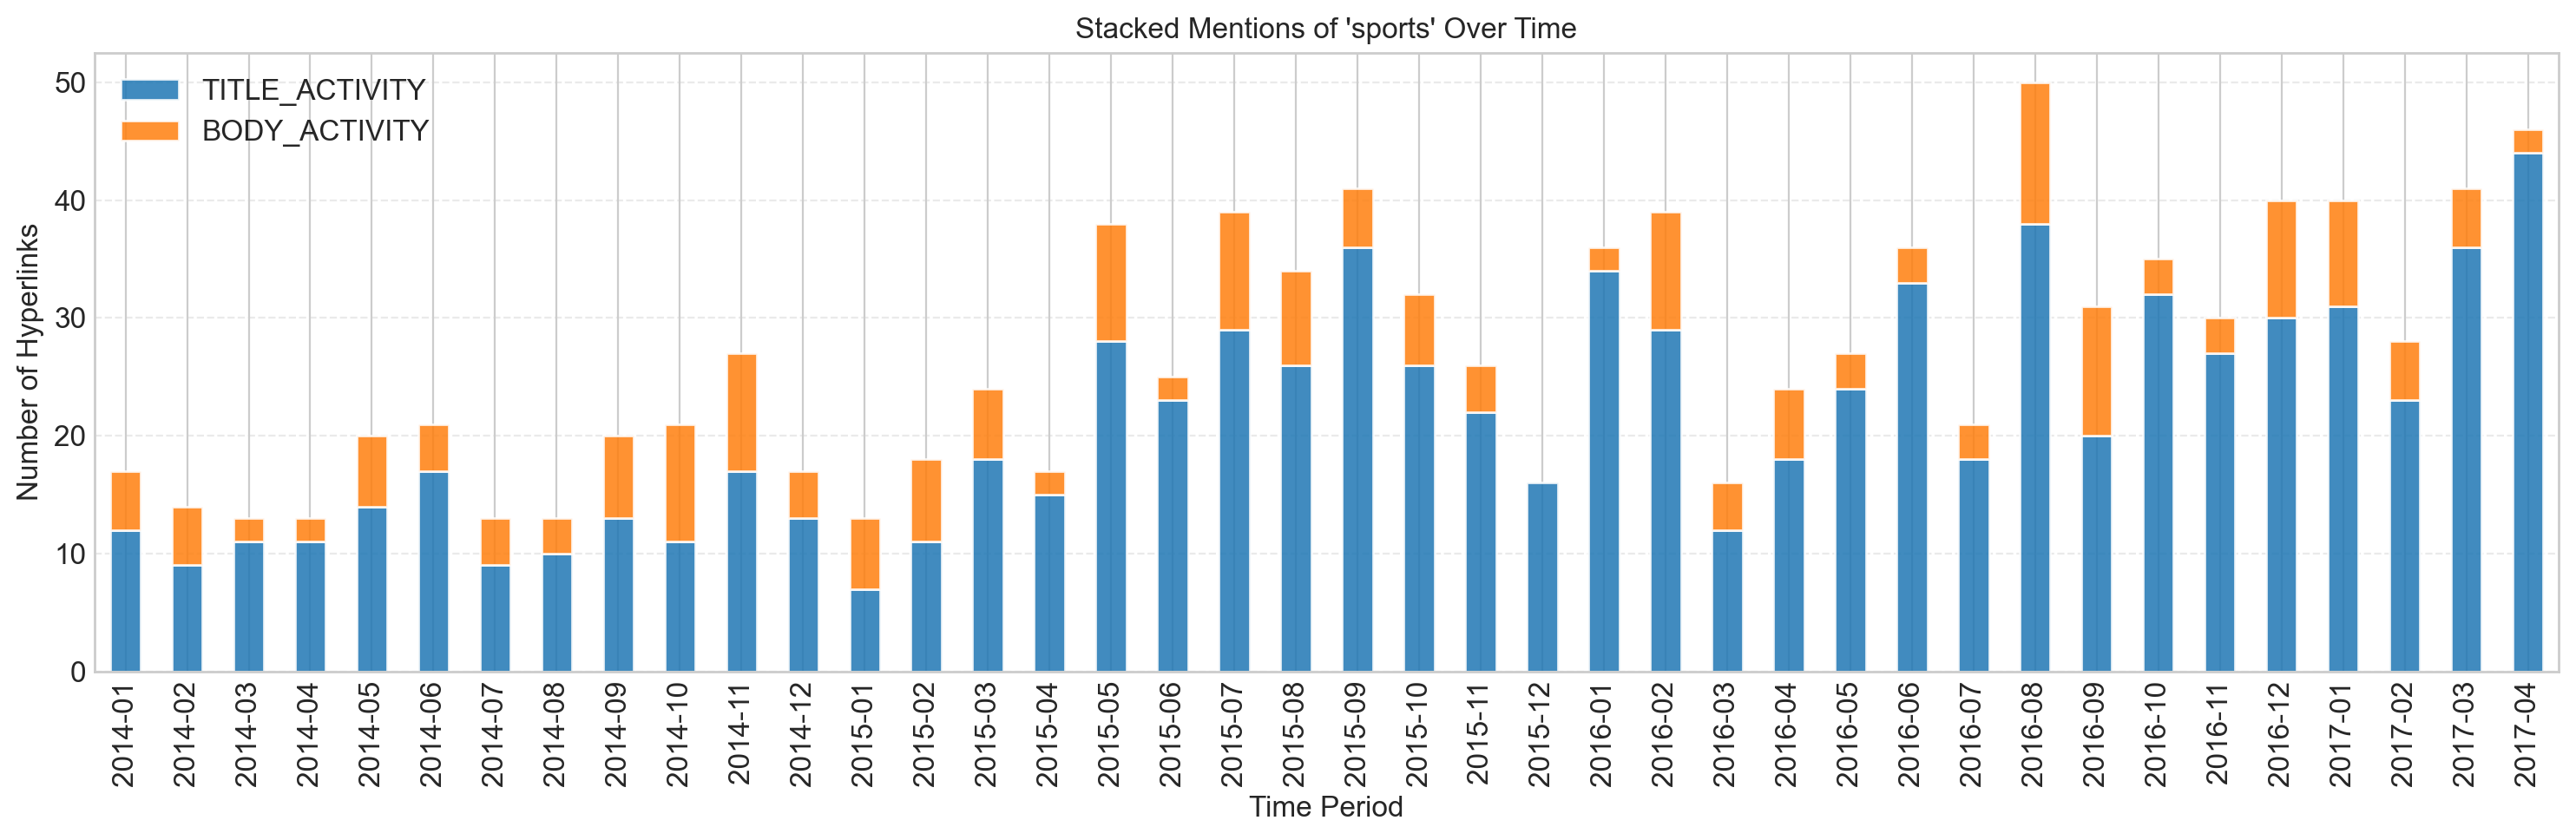

In [7]:
PATTERN = "sports"
df_counts = count_pattern_by_period(df_body, df_title, pattern = PATTERN, period = "M")
plot_activity_over_time(df_counts, pattern = PATTERN)

## Politics

We can first define the kind of interactions between left and right political sides and check for changes around the 2016 US elections. We start by checking the source POV, meaning who is generating which kind of interactions.

array([[1.18776850e+00, 1.46027443e-01, 5.48687795e-02, 4.23218790e+00,
        4.40184130e-02, 3.18259707e-02, 3.23504506e-01, 1.70390796e+00,
        1.21381435e+00, 4.89217311e-01],
       [2.06583680e+00, 4.55769047e-01, 1.28004264e-01, 8.41689502e+00,
        6.79413343e-02, 1.44066642e-02, 7.21147738e-01, 4.09918144e+00,
        2.61776655e+00, 1.42500689e+00],
       [1.45794416e-01, 3.05549659e-02, 3.54641250e-02, 7.01376399e-01,
        1.32802125e-03, 5.20833333e-03, 2.79136889e-02, 3.10855901e-01,
        1.97463376e-01, 1.12064503e-01],
       [2.00680354e-01, 1.46157710e-02, 0.00000000e+00, 7.01196902e-01,
        0.00000000e+00, 4.78468900e-03, 1.27624309e-02, 2.49589020e-01,
        2.19400540e-01, 3.01884797e-02],
       [8.89827142e-02, 2.13095467e-02, 0.00000000e+00, 4.61324123e-01,
        0.00000000e+00, 0.00000000e+00, 2.80898876e-03, 2.21024162e-01,
        1.99887216e-01, 2.11369452e-02],
       [4.96699670e-02, 6.60066007e-03, 0.00000000e+00, 1.88778878e-01,
   

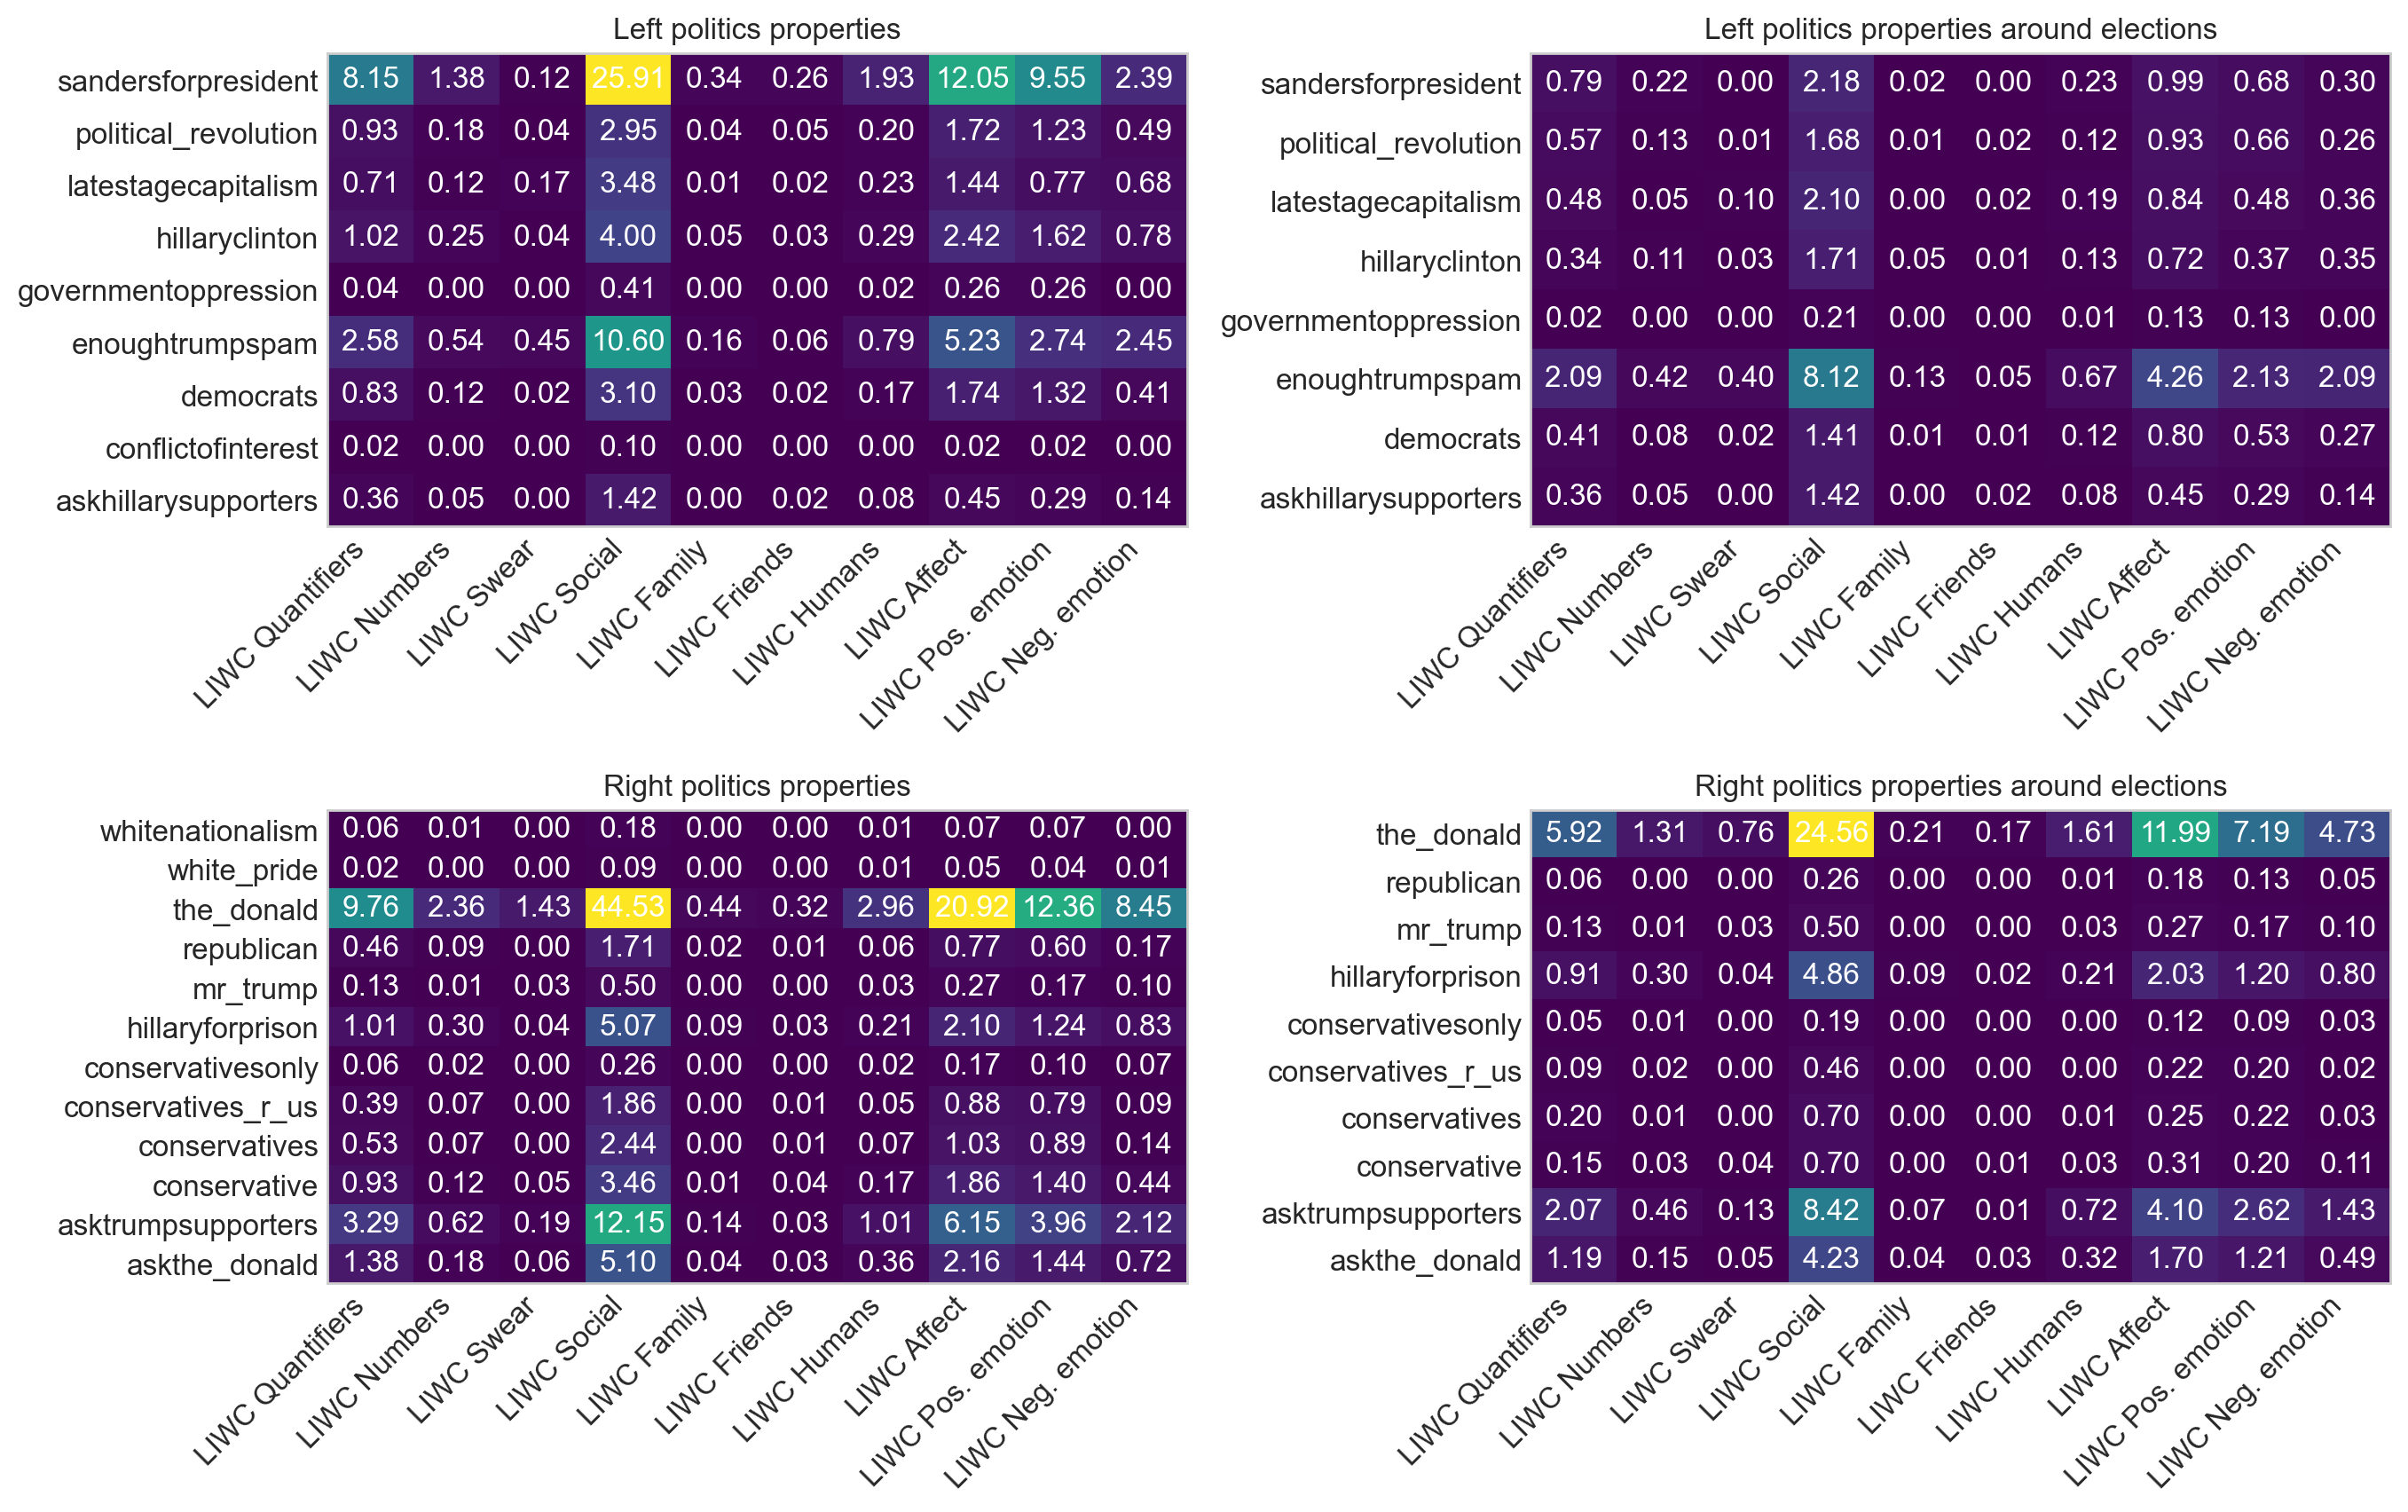

In [15]:
fig, ax = plt.subplots(2, 2, figsize = (PLOT_WIDTH, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)

size_properties = 10
start_properties = 40

plot_liwc_heatmaps(ax[0][0], df_body, LEFT_SUBREDDITS, size_properties=size_properties, start_properties=start_properties, title="Left politics properties", vmax=20)
plot_liwc_heatmaps(ax[1][0], df_body, RIGHT_SUBREDDITS, size_properties=size_properties, start_properties=start_properties, title="Right politics properties", vmax=20)
plot_liwc_heatmaps(ax[0][1], df_body, LEFT_SUBREDDITS, size_properties=size_properties, start_properties=start_properties, title="Left politics properties around elections", start_date='2016-05-01', end_date='2016-12-30', vmax=20)
plot_liwc_heatmaps(ax[1][1], df_body, RIGHT_SUBREDDITS, size_properties=size_properties, start_properties=start_properties, title="Right politics properties around elections", start_date='2016-05-01', end_date='2016-12-30', vmax=20)

Now we can also wonder who the left and right attack or help in these interactions.

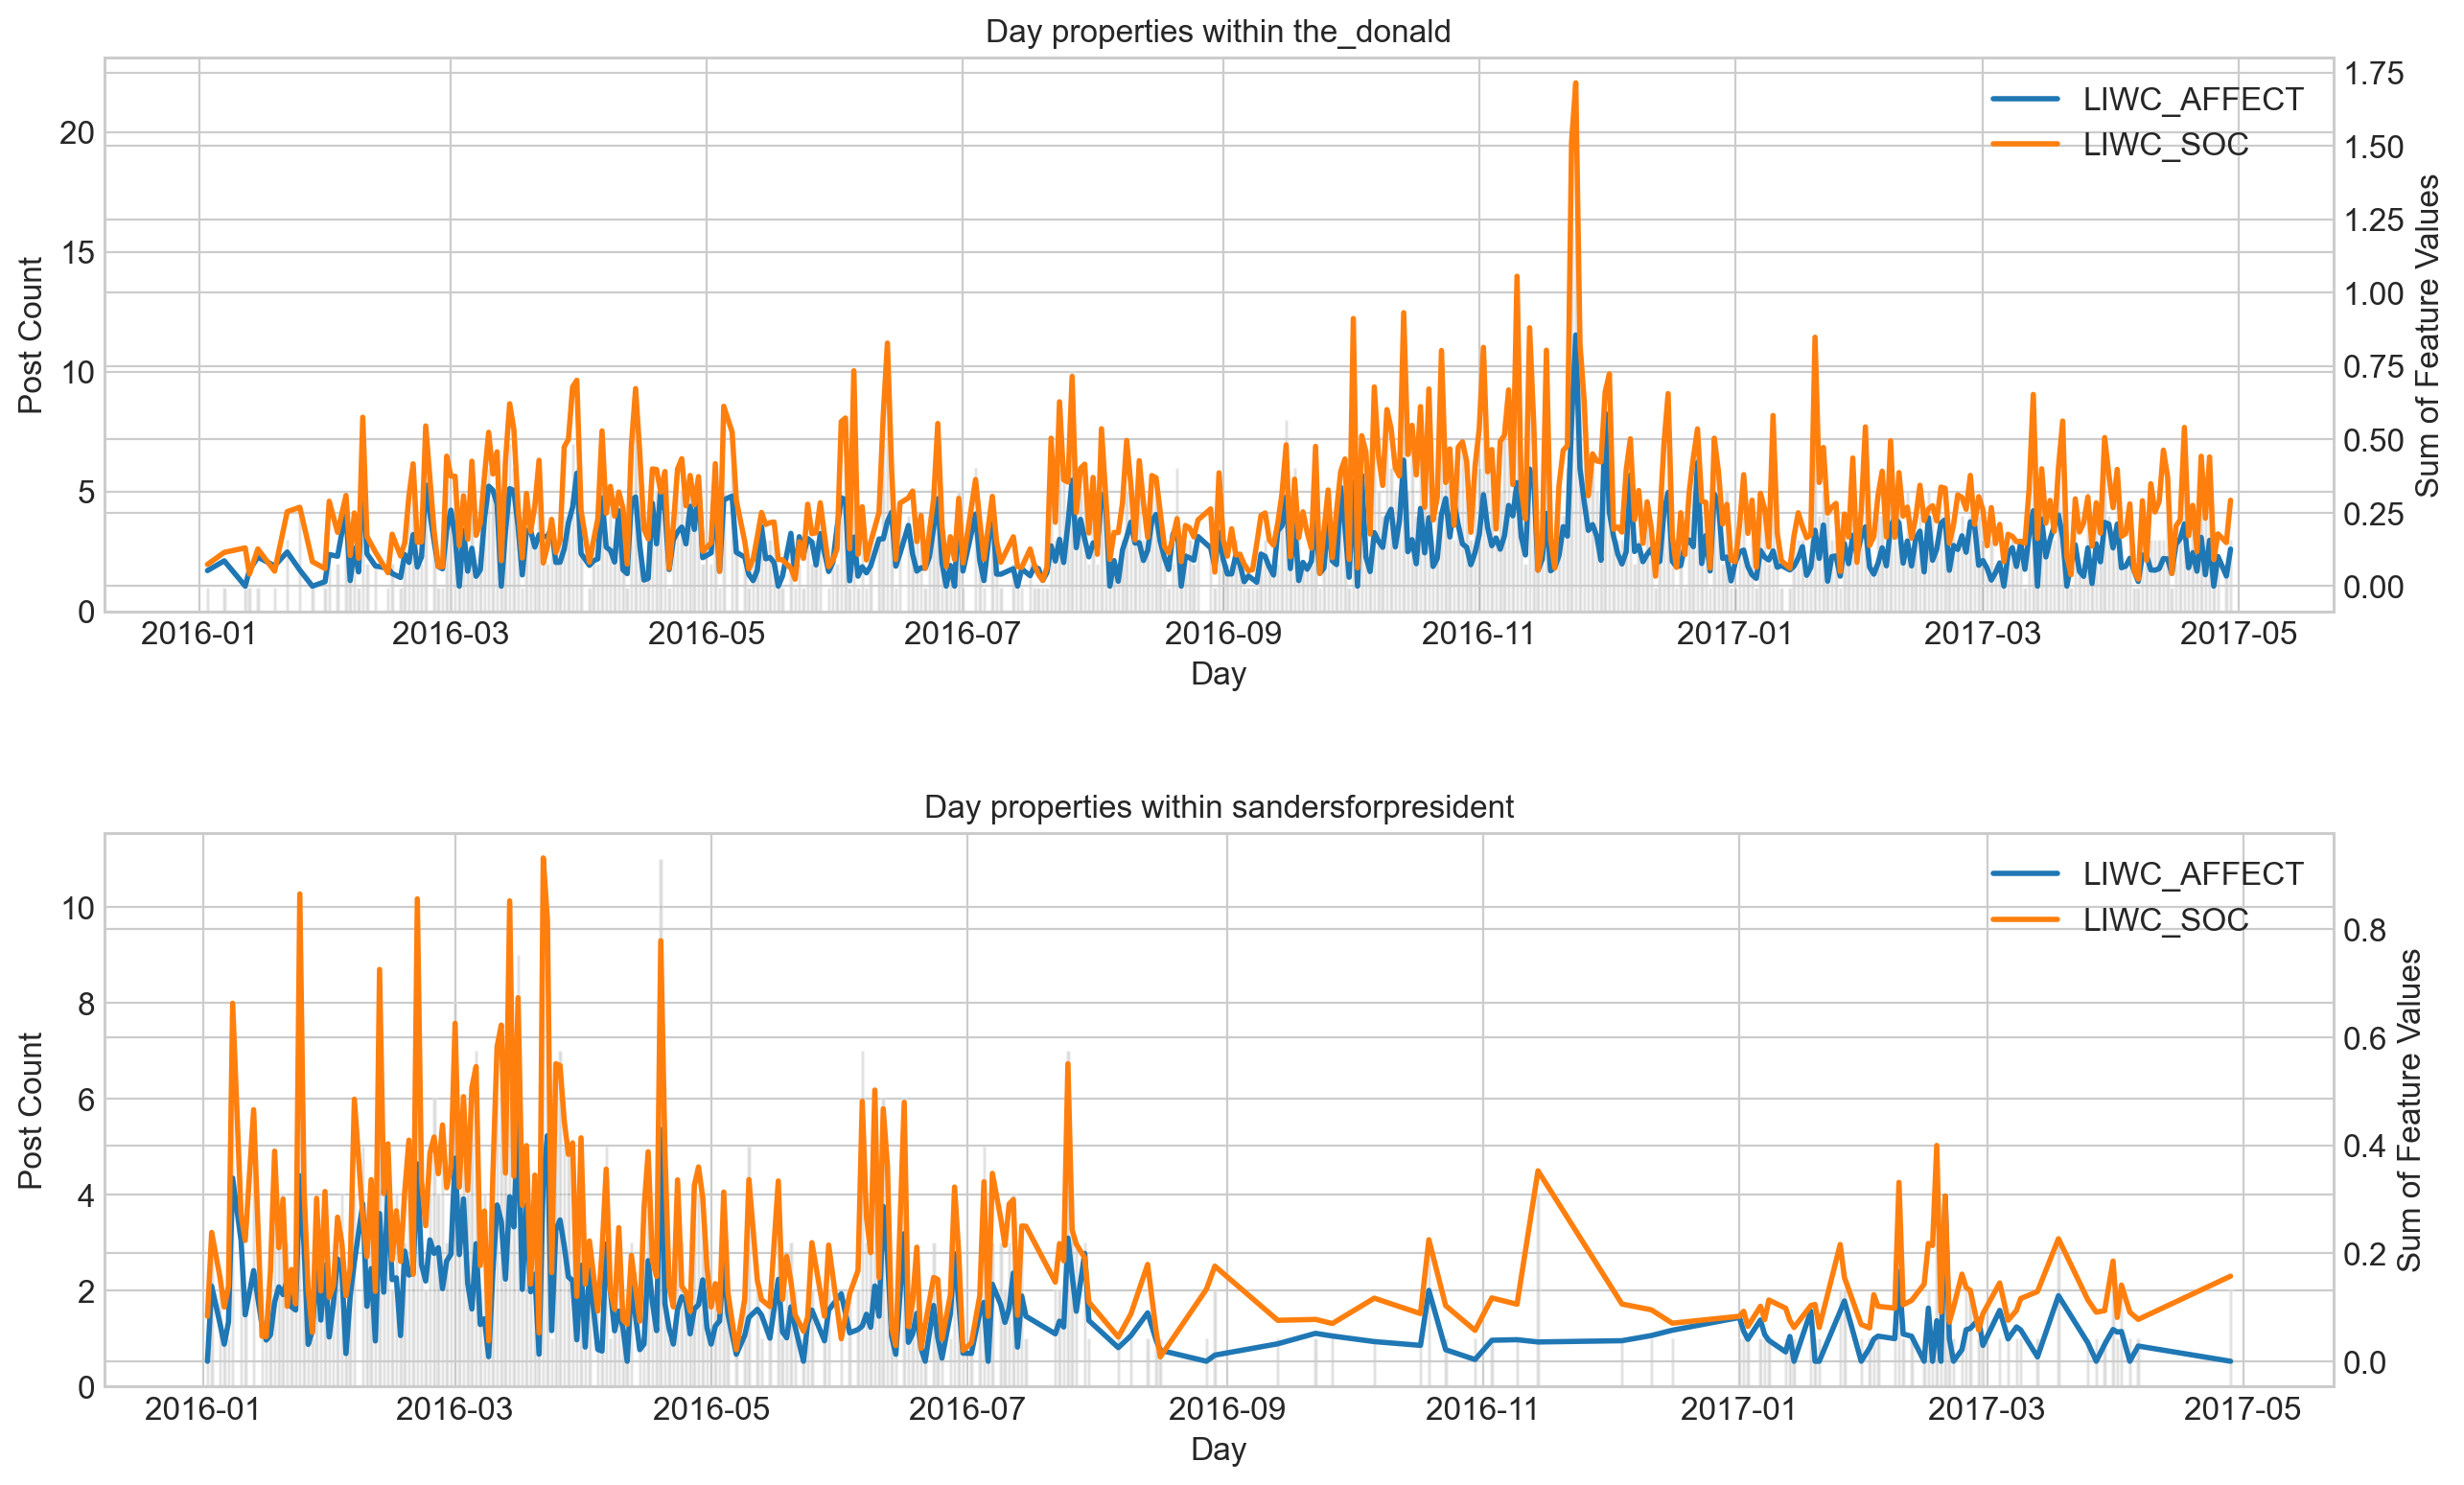

In [43]:
fig, ax = plt.subplots(2, figsize = (PLOT_WIDTH, 9))
plt.subplots_adjust(hspace=0.4)
features = ["LIWC_AFFECT", "LIWC_SOC"]
plot_subreddits_properties_trend(ax[0], df_body, ["the_donald"], '2016-01-01', DATA_END_DATE, features, period="D")
plot_subreddits_properties_trend(ax[1], df_body, ["sandersforpresident"], '2016-01-01', DATA_END_DATE, features, period="D")

Here we see that sandersforpresident has no data after half of July, which can be explained by the campagin stop at this date.

### Gaming

### Soccer

## Conclusion

We need to fill the content here

# PROJECT ENDS HERE, CONTENT BEFORE HAS BEEN REFACTORED
# THE CONTENT BELOW NEEDS TO BE MOVED TO THE CORRECT SECTION

## Methods
We wish to implement different methods to analyze the data. Here is some proof of concept.

The first method consists of finding clusters that match our 3 event categories (sports, political and holidays). We can't just pick the most active subreddits and analyze them since they have nothing to do with our categories.

Here's what we implement in order:
- Cluster the filtered subreddit data (this prevents us to look through thousands of subreddits one by one).
- Manually pick good subreddit names that match each category.
- Find nearest neighbors of the 3 created subreddit lists.

By the end of this section we'll be ready to start the exploratory analysis.

In [70]:
active_subreddits, total_counts = filter_active_subreddits(df_body, df_title, df_subreddits)
total = (total_counts['POST_COUNT_TOTAL'] < 20).sum()
print('Subreddits with less than 20 interactions:', total, 'out of', len(total_counts), '. Majority, so we will keep them for the moment.')

Subreddits with less than 20 interactions: 43868 out of 51278 . Majority, so we will keep them for the moment.


To cluster the subreddits, we use two approaches:
1. K-Means clustering (on the whole dataset)
2. Nearest neighbors (on the lists created on the previous step)

### K-Means Clustering
Here we are apllying K-means to cluster subreddits based on their similarities, thanks to the embeddings dataset:
- Dimensionality Reduction (PCA): we lower dimensional space to make clustering more efficient, while retaining most of the variance in the data.
- Optimal number of clusters: we test and evaluate different numbers of clusters using Silhouette Score and Davies-Bouldin Score.
- K-Means Clustering
- 2D Visualization (t-SNE)
- Results: We visualize clusters and manually identify those that macth our categories of interest.


In [6]:
from src.clustering import reduce_dimensions_pca

embeddings_pca, pca_model = reduce_dimensions_pca(active_subreddits.drop(columns=['SUBREDDIT']), n_components=50)
print(f"Explained variance: {pca_model.explained_variance_ratio_.sum():.2%}")

PCA explained variance ratio: 0.94
Explained variance: 94.22%


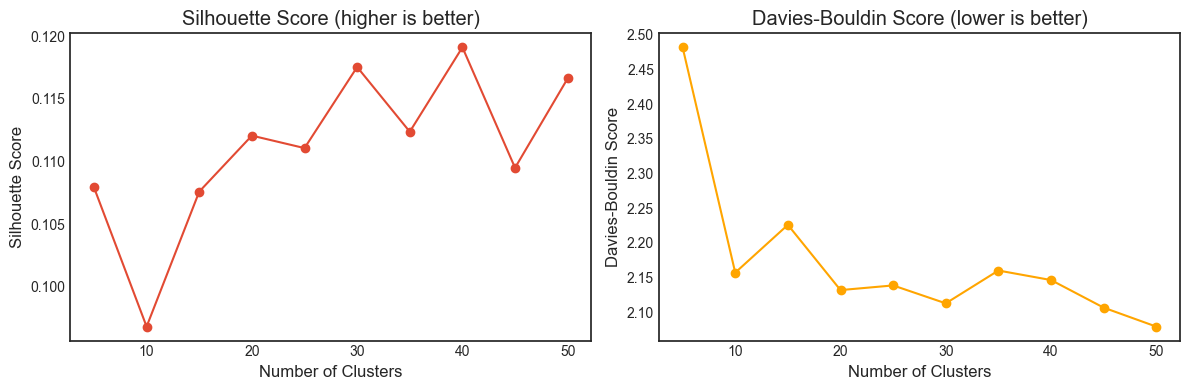

In [61]:
from src.clustering import evaluate_clustering_range

metrics_df = evaluate_clustering_range(embeddings_pca)
metrics_df[['n_clusters', 'silhouette_score', 'davies_bouldin_score']]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(metrics_df['n_clusters'], metrics_df['silhouette_score'], marker='o')
axs[0].set_title('Silhouette Score (higher is better)')
axs[0].set_xlabel('Number of Clusters')
axs[0].set_ylabel('Silhouette Score')

axs[1].plot(metrics_df['n_clusters'], metrics_df['davies_bouldin_score'], marker='o', color='orange')
axs[1].set_title('Davies-Bouldin Score (lower is better)')
axs[1].set_xlabel('Number of Clusters')
axs[1].set_ylabel('Davies-Bouldin Score')

plt.tight_layout()
plt.show()


We can see significant improvements in clustering quality up to around 20 clusters, after which the metrics stabilize. Therefore, we choose 20 as the optimal number of clusters for K-Means clustering.

In [8]:
from src.clustering import perform_kmeans_clustering

cluster_labels, kmeans_model = perform_kmeans_clustering(embeddings_pca)

In [9]:
from src.clustering import reduce_to_2d_tsne
embeddings_2d = reduce_to_2d_tsne(embeddings_pca)

Reducing 50D embeddings to 2D using t-SNE...
This may take a few minutes...


In [10]:
from src.clustering import create_cluster_visualization_df
viz_df = create_cluster_visualization_df(
    embeddings_2d,
    active_subreddits['SUBREDDIT'],
    cluster_labels
)

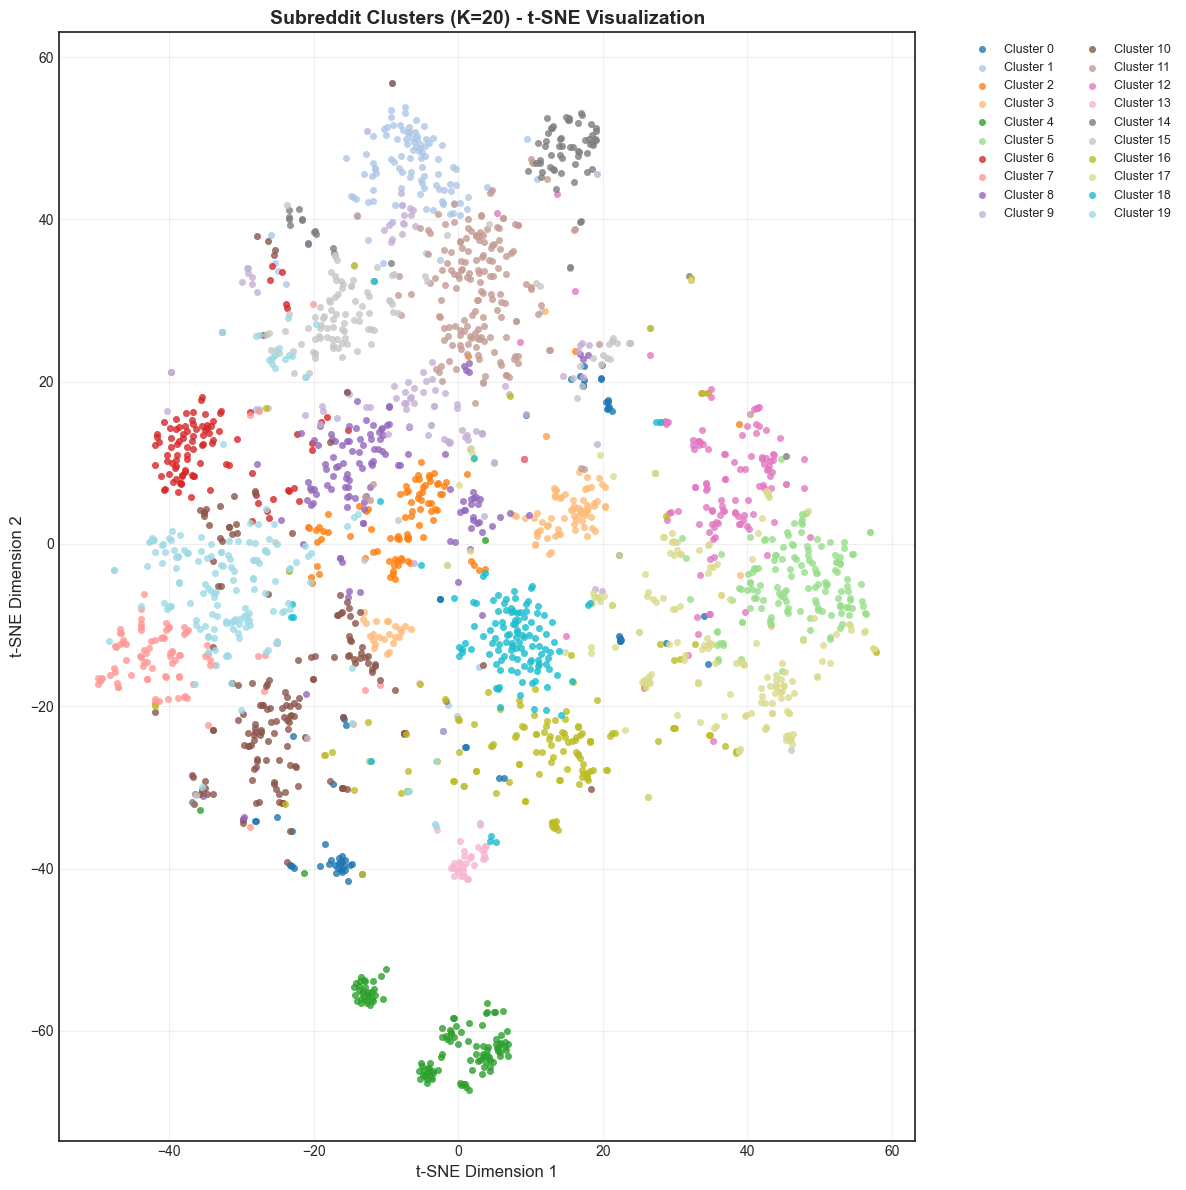

In [63]:
from src.visualization import plot_cluster_overview
plot_cluster_overview(
    viz_df
    #save_path='subreddit_clusters_tsne.png' TO ADD  !!!
);

### Top active subreddits per cluster

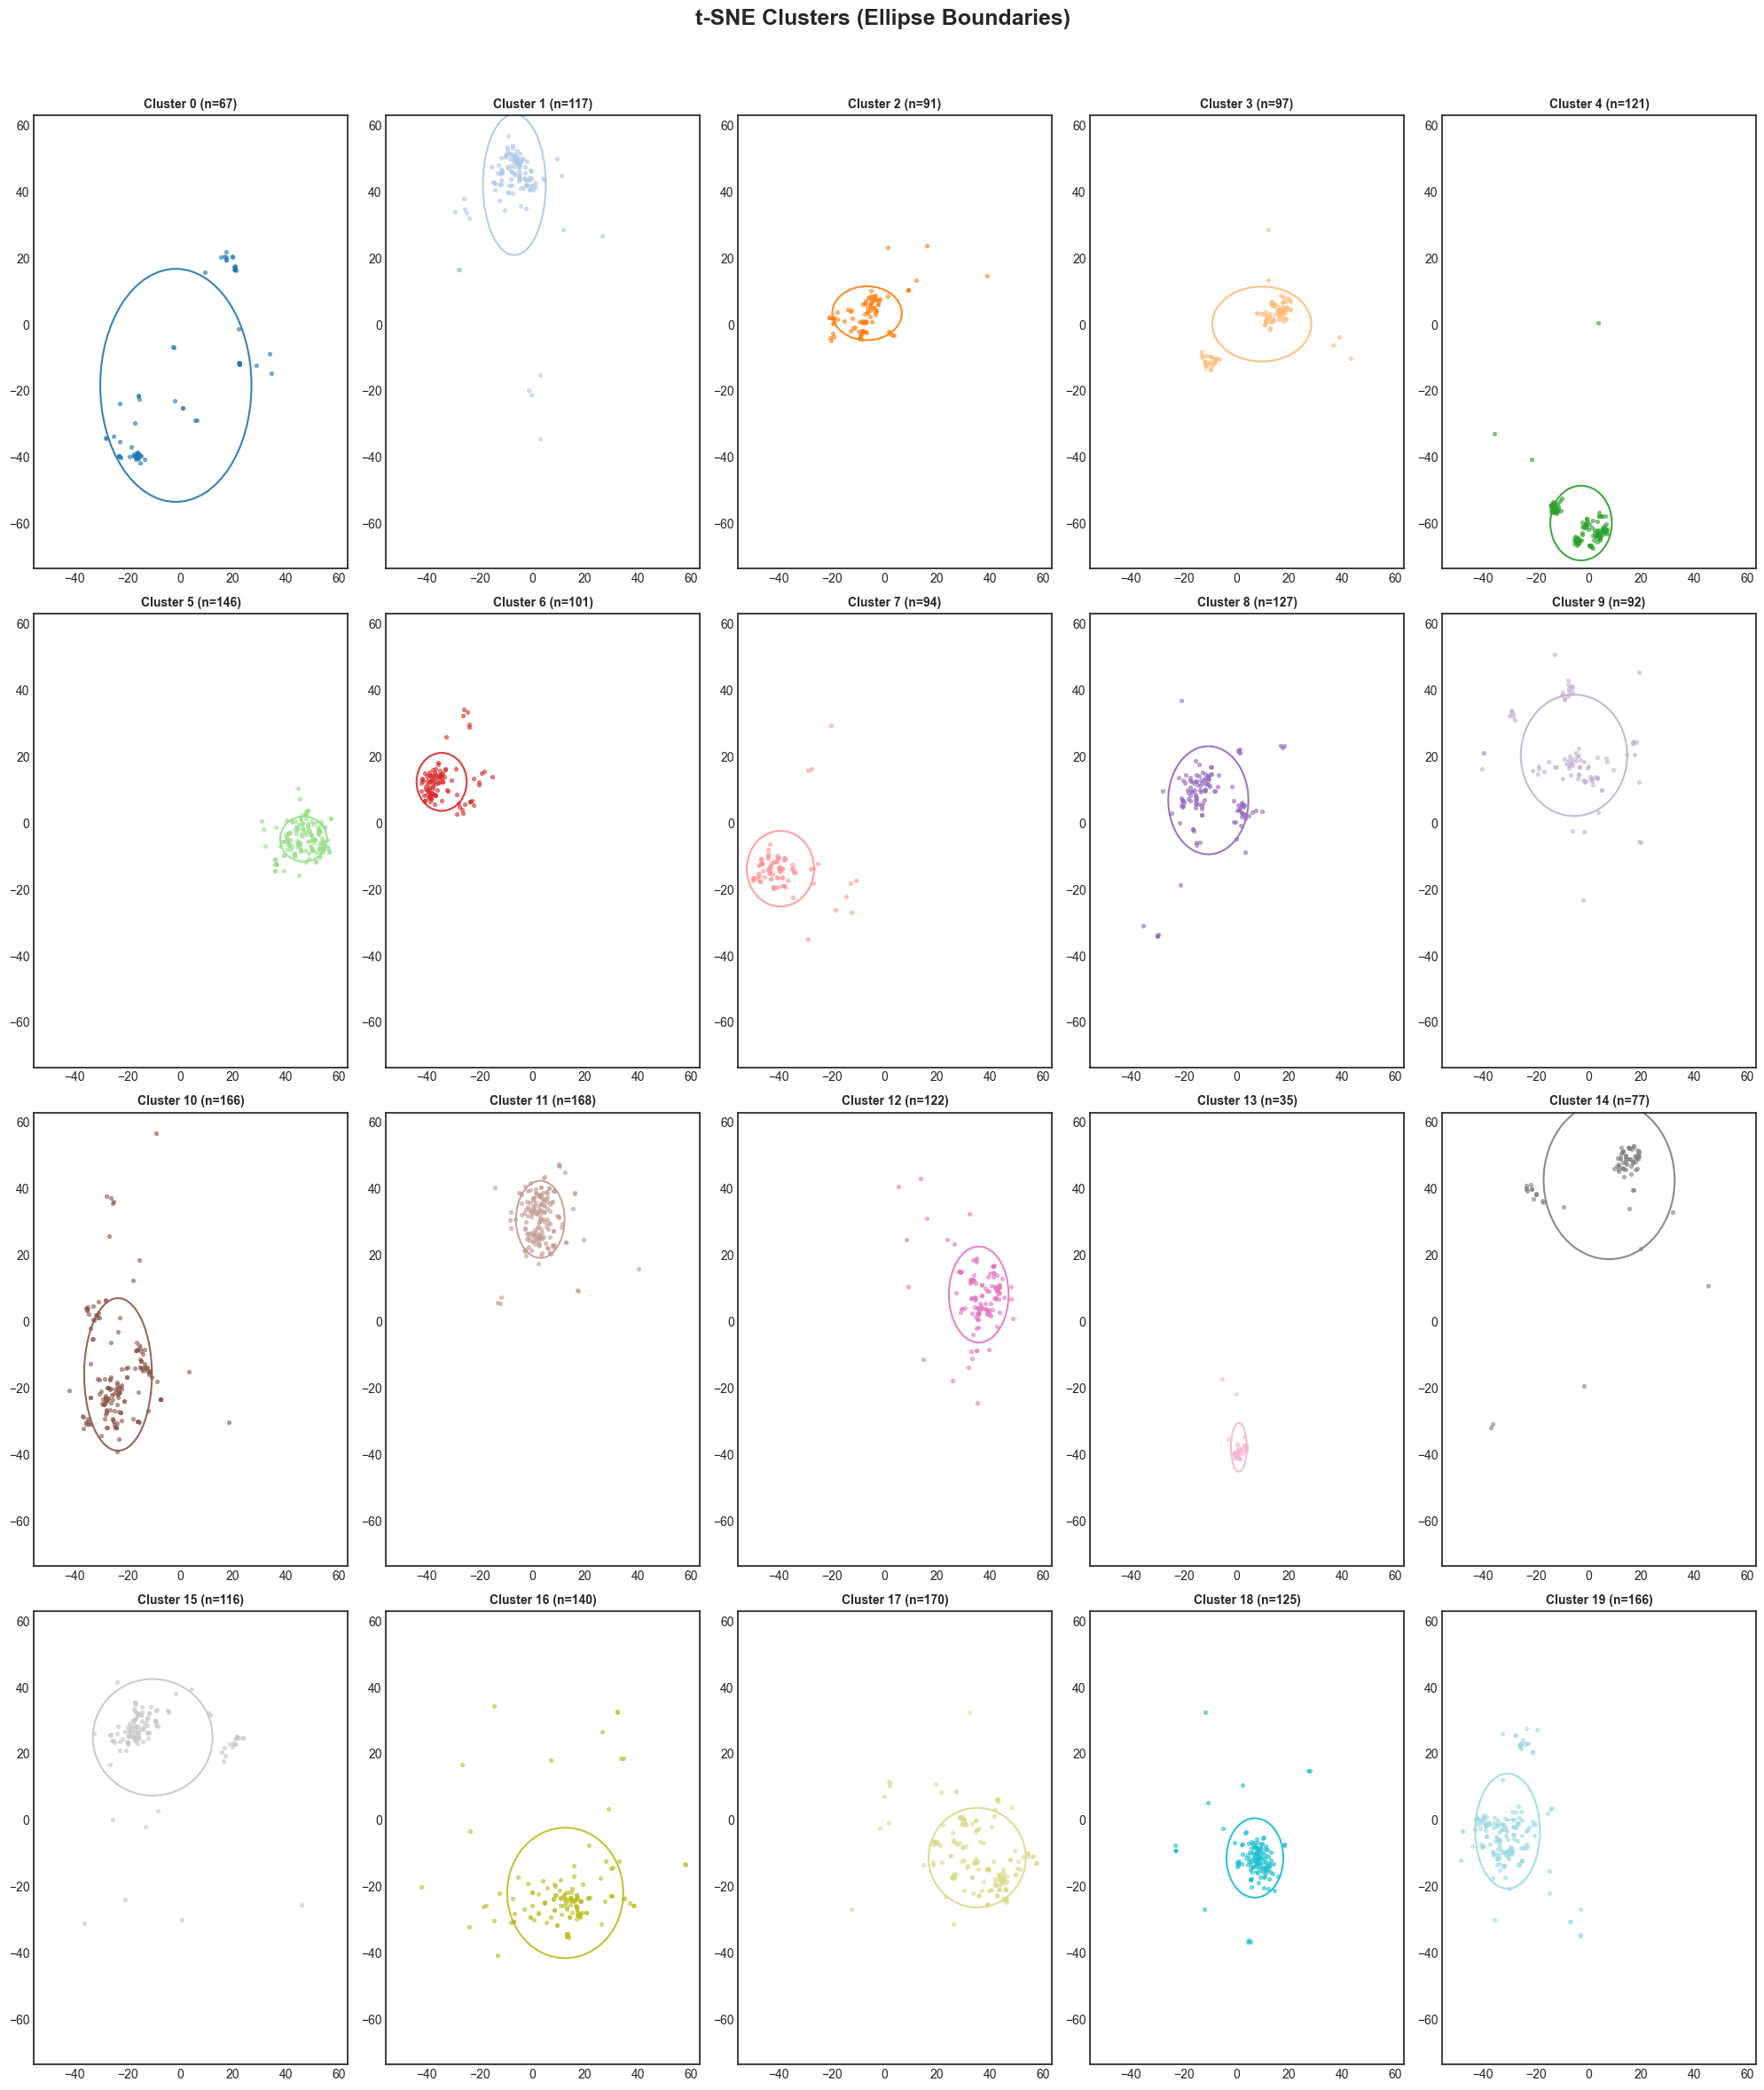

In [64]:
from src.visualization import plot_cluster_grid

# Create cluster grid visualization
fig = plot_cluster_grid(
    viz_df
    # save_path='cluster_grid_tsne.png'  # Uncomment to save
)


In [13]:
from src.consts import OPTIMAL_K, THEMES_SEEDS, LEFT_SUBREDDITS, RIGHT_SUBREDDITS

# Define columns to display
columns_show = ['SUBREDDIT', 'POST_COUNT_SOURCE', 'POST_COUNT_TARGET', 'POST_COUNT_TOTAL']

# Display top 5 active subreddits for each cluster
for cluster_id in range(OPTIMAL_K):
    # Get all subreddits in this cluster
    cluster_subreddits = viz_df[viz_df['cluster'] == cluster_id]['subreddit'].tolist()

    # Filter total_counts and get top 5 by total post count
    cluster_stats = (
        total_counts[total_counts['SUBREDDIT'].isin(cluster_subreddits)]
        .sort_values(by='POST_COUNT_TOTAL', ascending=False)
        .head(5)[columns_show]
    )

    print(f"\n{'='*60}")
    print(f"Cluster {cluster_id} - Top 5 Subreddits (n={len(cluster_subreddits)})")
    print(f"{'='*60}")
    display(cluster_stats)


Cluster 0 - Top 5 Subreddits (n=67)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
41492,soccer,942.0,3775.0,4717.0
16030,fitnesscirclejerk,3324.0,136.0,3460.0
20497,hiphopheads,441.0,1280.0,1721.0
23075,jailbreak,545.0,596.0,1141.0
28957,mls,265.0,738.0,1003.0



Cluster 1 - Top 5 Subreddits (n=117)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
5014,bestof,21170.0,1459.0,22629.0
34236,pics,253.0,12578.0,12831.0
45964,todayilearned,1294.0,11124.0,12418.0
17211,funny,979.0,10777.0,11756.0
48477,videos,341.0,10013.0,10354.0



Cluster 2 - Top 5 Subreddits (n=91)


...

,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
25392,leagueoflegends,1346.0,4856.0,6202.0
18569,globaloffensive,687.0,2128.0,2815.0
2197,anime,676.0,2014.0,2690.0
20108,hearthstone,710.0,1601.0,2311.0
11975,destinythegame,558.0,1399.0,1957.0



Cluster 18 - Top 5 Subreddits (n=125)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
10981,dailydot,944.0,2.0,946.0
8112,changelog,46.0,748.0,794.0
47622,unexpectedhogwarts,732.0,4.0,736.0
45620,threadkillers,516.0,4.0,520.0
47620,unexpectedfactorial,475.0,1.0,476.0



Cluster 19 - Top 5 Subreddits (n=166)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
35083,politics,560.0,6114.0,6674.0
40369,shitliberalssay,3765.0,157.0,3922.0
38985,sandersforpresident,1012.0,2845.0,3857.0
3470,atheism,1222.0,2369.0,3591.0
4131,badphilosophy,3021.0,259.0,3280.0


We chose the following cluster in order to create 3 subreddit lists related to sports, politics and holidays, note that the lists will be further refined in P3:
- Sports: clusters 4
- Politics: clusters 7, 10, 19
- Gaming: clusters 5, 16, 17

It seems that holiday subreddits are not very active on Reddit, so we may need to change the approach or the category all together.

In [14]:
# Example of inspecting a specific cluster
list(viz_df[viz_df['cluster'] == 17]["subreddit"]) # related to sports

['leagueoflegends',
 'globaloffensive',
 'destinythegame',
 'overwatch',
 'hearthstone',
 'wow',
 '2007scape',
 'pokemongo',
 'smite',
 'runescape',
 'anime',
 'rocketleague',
 'hardwareswap',
 'pathofexile',
 'heroesofthestorm',
 'summonerschool',
 'clashofclans',
 'summonerswar',
 'warframe',
 'ffxiv',
 'guildwars2',
 'clashroyale',
 'blackops3',
 'h1z1',
 'starcraft',
 'playrust',
 'eve',
 'codzombies',
 'eu4',
 'fakeid',
 'osugame',
 'pokemongiveaway',
 'forhonor',
 'ultrahardcore',
 'twitch',
 'casualpokemontrades',
 'teamredditteams',
 'monsterhunter',
 'manga',
 'blackdesertonline',
 'feedthebeast',
 'yugioh',
 'diablo',
 'onepiece',
 'mechmarket',
 'playark',
 'codcompetitive',
 'ecigclassifieds',
 'mindcrack',
 'iosthemes',
 'archeage',
 'naruto',
 'diablo3',
 'worldoftanks',
 'pka',
 'shinypokemon',
 'ffrecordkeeper',
 'thesilphroad',
 'wildstar',
 'customhearthstone',
 'streetfighter',
 'animesuggest',
 'codaw',
 'pokemonplaza',
 'wowguilds',
 'ssbpm',
 'swgalaxyofheroes',
 

In [35]:
from src.clustering import similarity_subreddits

display(sim_gaming.head())
display(sim_politics.head())
display(sim_sports.head())

,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
2,globaloffensivetrade,-0.023145,-1.199374,1.661484,-1.025296,1.424670,-1.179507,-1.035703,0.329301,-0.567272,...,2.998430,-1.235703,-0.326850,4.381238,-1.965378,-2.369674,-0.615389,2.010601,-0.919314,-2.149625
3,fireteams,2.492506,-2.529917,-0.448484,-3.543441,-0.586122,-0.101517,1.837567,-0.215715,-2.460388,...,-1.875214,0.969291,0.497958,2.941132,2.423561,1.315691,-0.959618,0.151845,-0.852492,-0.467526
8,leagueoflegends,-2.785298,-0.166391,1.592624,-1.269829,2.861522,-1.785990,-0.792381,0.251381,-0.175915,...,-0.121036,-0.609562,-0.662614,0.799229,0.233212,1.966991,-2.644099,2.571104,-1.561871,0.203770
9,rocketleagueexchange,0.553341,-3.283354,-3.091485,0.877085,3.420619,-1.589593,1.644614,-2.153739,-3.075733,...,0.567491,-2.932517,-1.128070,2.021096,-0.953196,-0.887449,-0.838263,-0.010218,0.415019,0.380263
12,gaming,-0.592067,0.182106,0.479194,-0.051405,0.364937,0.778634,0.268826,-1.538470,-0.202311,...,-0.314182,0.326358,-0.234719,-1.385476,1.033845,0.552970,-0.626990,-0.008179,0.722172,1.897383


,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
5,the_donald,-0.123265,-0.610208,0.361495,-1.171773,0.367407,0.624919,2.420601,-0.447998,1.393862,...,0.981761,1.044754,-2.334628,-0.005856,-1.647531,-0.139574,-0.284726,0.315069,-0.846018,0.800535
46,politic,-0.093657,-0.408756,-0.416751,-0.745158,-0.405475,-0.476495,1.024330,0.509578,-0.574825,...,-0.185134,0.782819,-0.116337,1.356275,-0.583907,0.659083,-0.115163,1.575137,0.358196,-0.533359
57,conspiracy,0.233638,-0.029371,-0.021613,-1.667570,0.325102,-2.431795,2.380274,1.175025,0.721296,...,-0.087238,-0.191128,-0.842286,0.589056,-0.623826,1.366514,-0.138907,0.912282,0.846551,1.048208
197,conservative,-0.328812,0.360963,0.411680,-1.508632,0.412306,-0.342744,1.504849,1.108759,0.111182,...,0.679122,1.293226,-0.256007,0.002481,-0.444183,-0.102819,0.487783,-0.337940,1.037298,0.262405
204,worldpolitics,0.090303,-0.266275,-0.274545,-1.282758,0.167097,-1.388583,0.955915,0.100589,0.260755,...,0.284267,0.098816,-0.603549,1.067378,0.115976,0.259016,-0.273216,0.499261,0.134240,-0.694680


,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
43,nba,-0.337707,0.748252,-0.542450,-1.183674,0.977801,-0.303711,1.199204,0.070239,-0.824186,...,2.781084,0.725929,-0.599088,1.684985,-1.447476,-0.293888,0.320813,0.011611,-0.317726,1.881141
76,nfl,-0.413744,0.135593,-0.375919,-2.155808,0.364753,-0.128381,0.669011,0.528798,0.360201,...,0.766757,0.111257,0.474236,0.441049,-0.866072,-0.453644,0.378248,-0.026019,0.105829,0.850837
120,hockey,-0.087811,0.070745,0.212309,-0.853731,0.300142,-1.816659,1.825596,0.169254,0.423413,...,1.065411,-0.301631,-0.428294,0.094620,-1.470184,-1.255917,-0.559597,-0.332883,-0.865914,1.510437
133,fantasyfootball,-0.046710,-0.303285,-0.785278,-1.798292,-0.185130,-1.617117,1.798600,0.342118,-0.453294,...,-0.348719,-0.649680,0.064886,0.399210,-0.228876,-0.290961,-0.682324,0.352131,-0.396168,1.000266
175,cfb,-0.542290,1.074772,0.236502,-1.676222,-0.081229,0.214127,1.127829,-0.139393,0.072891,...,1.852311,0.124809,-0.539539,1.198687,-1.998423,-0.672317,-0.046156,-1.064728,0.205887,1.649268


With these methods, we were able to create subreddit lists for sports, gaming and politics. These lists will be used in the exploratory analysis phase to study the impact of major events on Reddit activity and interactions.

This analysis will mainly focus on the LIWC features and activity patterns. The goal will be to identify the behavior and analyze the type of interaction between the subreddits.